In [1]:
# !pip3 install -r ../requirements.txt

In [21]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../') # move one level up to the base path
from src.utils import load_and_preprocess_images # import the helper functions

In [4]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [3]:
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/synthetic'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet/TestSet'

realDataPath = repo_path + '/data/real'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [19]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

comment = "dropout 0.3 again_final"

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
DATA_AUG_RATE = 0.1
EPOCHS = 100
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001
LOSS_FUNCTION = 'sparse_categorical_crossentropy'
OPTIMIZER = SGD(learning_rate=LEARNING_RATE)

In [17]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (956481403.py, line 1)

In [6]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


In [7]:
def initialize_model(mn_output_layer, unfreeze_from_layer, loss_function, optimizer, dropout_rate, regularization_rate, input_shape=INPUT_SHAPE):

    # Load the MobileNetV2 model    
    pretrained_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the pretrained weights
    pretrained_model.trainable = False

    # Unfreeze the layers starting from unfreeze_from_layer (exclusive)
    unfreeze = False
    for layer in pretrained_model.layers:
        if unfreeze:
            layer.trainable = True
        elif layer.name == unfreeze_from_layer:
            layer.trainable = False
            unfreeze = True

    # Ensure BN layers are in inference mode (batch norm layers are not trainable)
    for layer in pretrained_model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        
    last_layer = pretrained_model.get_layer(mn_output_layer)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    model = Sequential(name='baseline_model')
    model.add(Input(shape=input_shape))
    model.add(base_model)
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax'))

    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [8]:
model_file_path = repo_path + f"/models/baseline_model/ckpt/{comment}_checkpoint.model.keras"

early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=20, start_from_epoch=10)
checkpoint = ModelCheckpoint(model_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

model = initialize_model(mn_output_layer=MN_OUTPUT_LAYER, unfreeze_from_layer=UNFREEZE_FROM_LAYER, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

In [24]:
# model.summary(show_trainable=True)

In [10]:
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
    )

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.4612 - loss: 8.0788
Epoch 1: val_accuracy improved from -inf to 0.74323, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/baseline_model/ckpt/dropout 0.3 again_final_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 848ms/step - accuracy: 0.4624 - loss: 8.0750 - val_accuracy: 0.7432 - val_loss: 7.3018 - learning_rate: 1.0000e-04
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.6671 - loss: 7.5117
Epoch 2: val_accuracy improved from 0.74323 to 0.84000, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/baseline_model/ckpt/dropout 0.3 again_final_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 725ms/step - accuracy: 0.6675 - loss: 7.5107 - val_accuracy: 0.8400 - val_loss: 7.1502 - learning_rate: 1.0000e-04
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7548 - loss: 7.3014
Epoch 3: v

In [16]:
# save the history of the training
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(repo_path + f"/models/baseline_model/history/{comment}_history.csv", index=False)

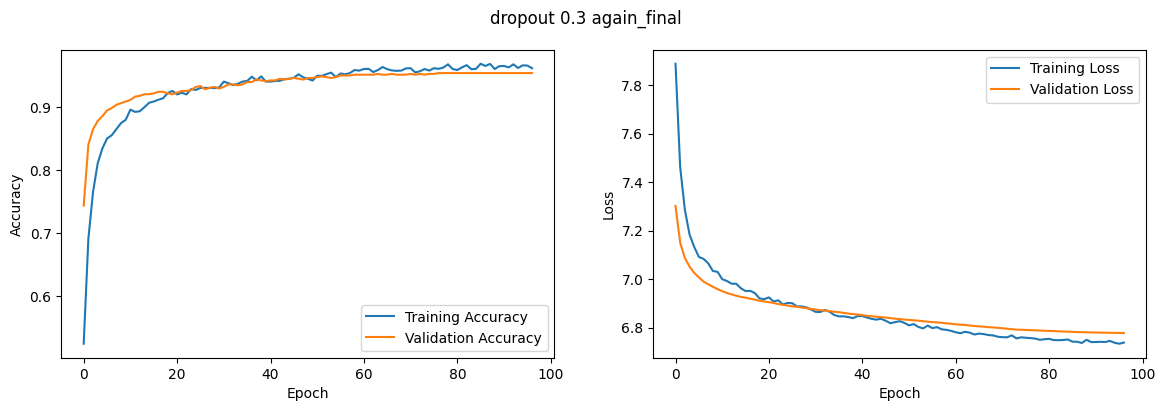

Best train_accuracy: 0.9684
Best train_loss: 6.7335
Best val_accuracy: 0.9535
Best val_loss: 6.7774
Last improvement at epoch: 77


In [11]:
# plot accuracy and loss
plt.figure(figsize=(14, 4))

# plot headline
plt.suptitle(comment)

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# get the best val_accuracy and val_loss
best_train_accuracy = np.max(history.history['accuracy']).round(4)
best_train_loss = np.min(history.history['loss']).round(4)
best_val_accuracy = np.max(history.history['val_accuracy']).round(4)
best_val_loss = np.min(history.history['val_loss']).round(4)

print(f'Best train_accuracy: {best_train_accuracy}')
print(f'Best train_loss: {best_train_loss}')
print(f'Best val_accuracy: {best_val_accuracy}')
print(f'Best val_loss: {best_val_loss}')
print(f'Last improvement at epoch: {np.argmax(history.history["val_accuracy"])+1}')

In [23]:
real_train_data_augm = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2, skip_preprocessing=True)
real_train_data_orig = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, skip_preprocessing=True)

def plot_images(img_orig, img_augm, num_images=5):
    plt.figure(figsize=(15, 6))
    images_displayed = 0

    # Take one batch from each dataset
    for (images1, _), (images2, _) in zip(img_orig.take(1), img_augm.take(1)):
        for i in range(num_images):
            if images_displayed >= num_images:
                break

            # Plot original image
            plt.subplot(2, num_images, images_displayed + 1)
            plt.imshow(images1[i].numpy().astype("uint8"))
            plt.title(f"Original")
            plt.axis("off")

            # Plot augmented image
            plt.subplot(2, num_images, images_displayed + num_images + 1)
            plt.imshow(images2[i].numpy().astype("uint8"))
            plt.title(f"Augmented")
            plt.axis("off")

            images_displayed += 1

# Plotting original and augmented images
plot_images(img_orig=real_train_data_orig, img_augm=real_train_data_augm)

TypeError: load_and_preprocess_images() got an unexpected keyword argument 'data_aug_rate'

Found 3876 files belonging to 2 classes.
Using 775 files for validation.


2024-07-10 00:25:46.409841: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step


2024-07-10 00:25:47.500069: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


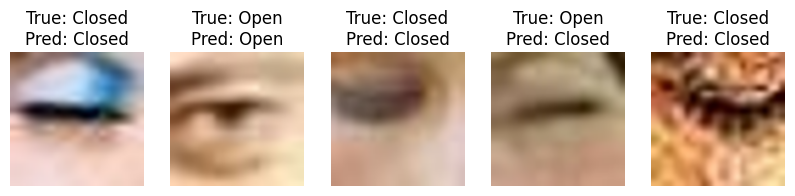

In [13]:
real_valid_data_skip_preprocessing = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, data_aug_rate=DATA_AUG_RATE, seed=SEED, subset='validation', validation_split=0.2, skip_preprocessing=True)

def plot_predictions(model, dataset, dataset_visual, class_names = ["Closed", "Open"], num_images=5):
    plt.figure(figsize=(10, 5))
    images_displayed = 0

    for (images, labels), (images_visual, _) in zip(dataset.take(1), dataset_visual.take(1)):
        predictions = model.predict(images)
        predicted_labels = tf.argmax(predictions, axis=1)

        for i in range(len(images)):
            if images_displayed >= num_images:
                break

            plt.subplot(1, num_images, images_displayed + 1)
            plt.imshow(images_visual[i].numpy().astype("uint8"))
            plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
            plt.axis("off")
            images_displayed += 1

# Plotting predictions from validation data
plot_predictions(model, real_valid_data, real_valid_data_skip_preprocessing)